# Сверточные нейронные сети

In [6]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import torchvision
import torchvision.transforms.v2 as T

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

## Загрузка изображения

Загрузим изображение из интернета, например, Питер Гриффина из одноименного мультсериала "Гриффины".

In [7]:
!wget "https://static.independent.co.uk/2021/10/29/14/newFile-8.jpg?width=1200" -O peter.jpg

--2025-11-07 18:43:53--  https://static.independent.co.uk/2021/10/29/14/newFile-8.jpg?width=1200
Resolving static.independent.co.uk (static.independent.co.uk)... 146.75.117.91
Connecting to static.independent.co.uk (static.independent.co.uk)|146.75.117.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 112326 (110K) [image/jpeg]
Saving to: ‘peter.jpg’

peter.jpg           100%[===================>] 109.69K  --.-KB/s    in 0.1s    

2025-11-07 18:43:54 (841 KB/s) - ‘peter.jpg’ saved [112326/112326]



## Чтение изображения

In [8]:
img = torchvision.io.read_image('peter.jpg')
type(img)

torch.Tensor

In [9]:
img.shape

torch.Size([3, 899, 1200])

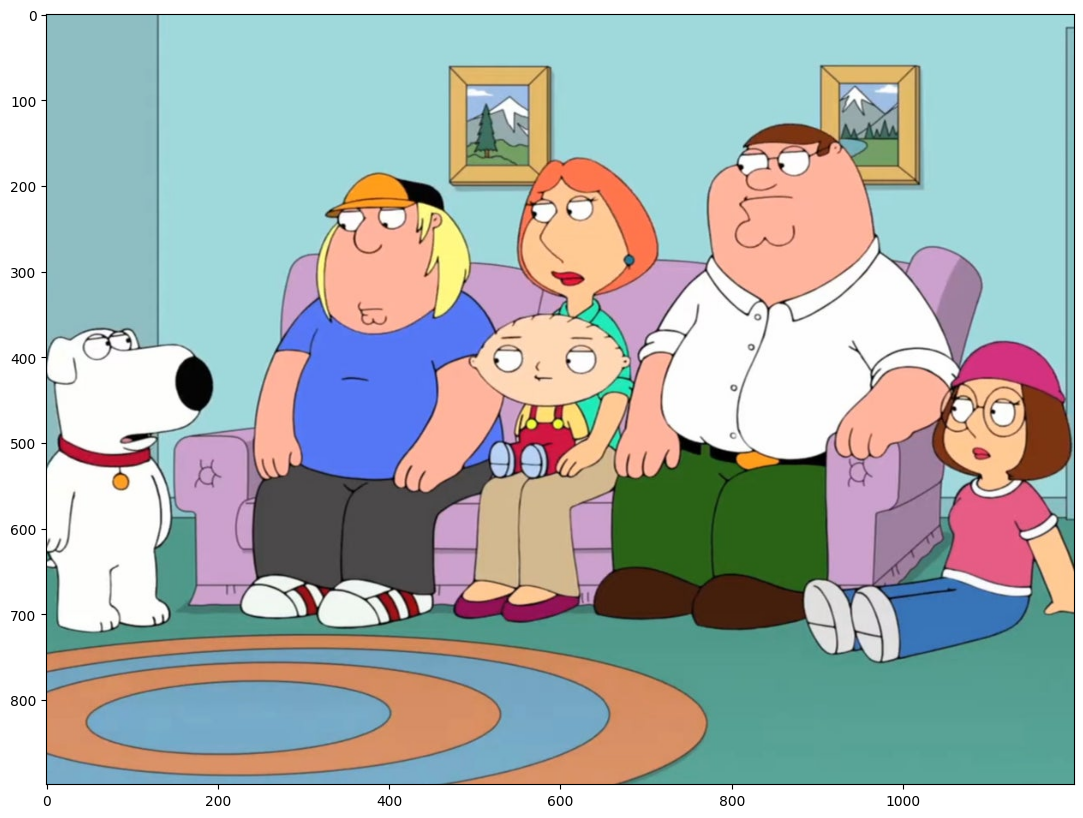

In [10]:
plt.figure(figsize=(20, 10))
plt.imshow(img.permute(1, 2, 0))
plt.show()

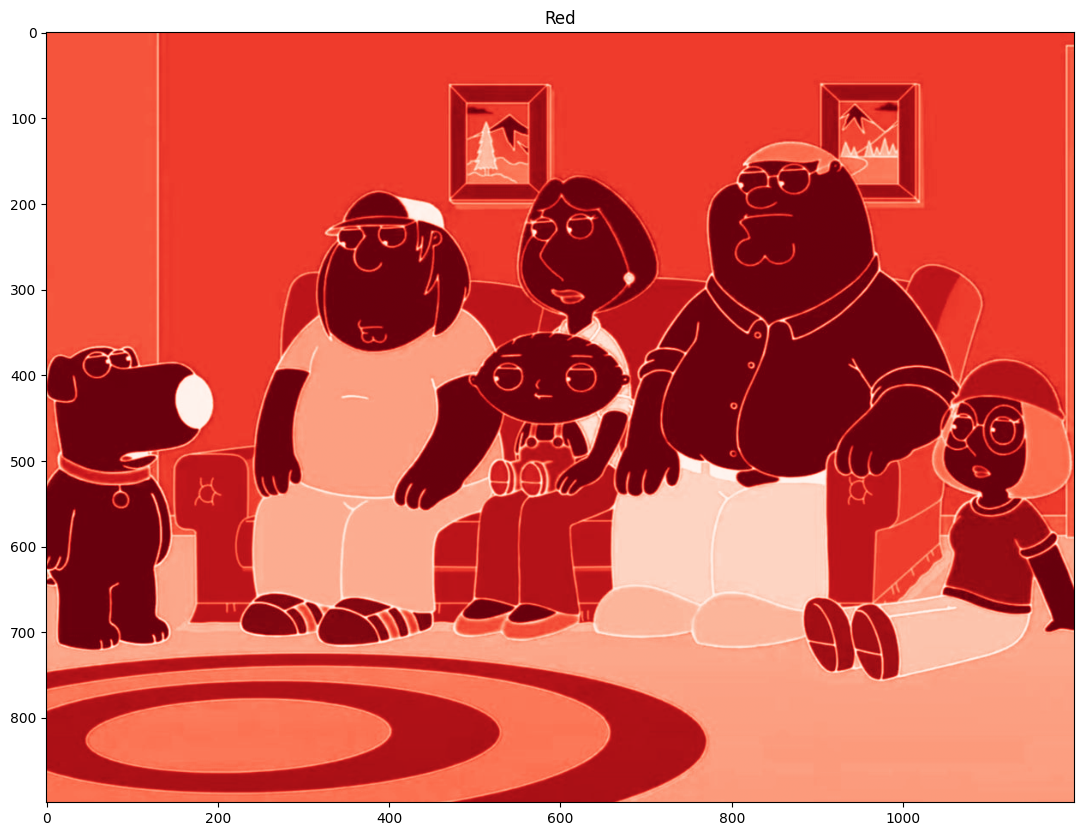

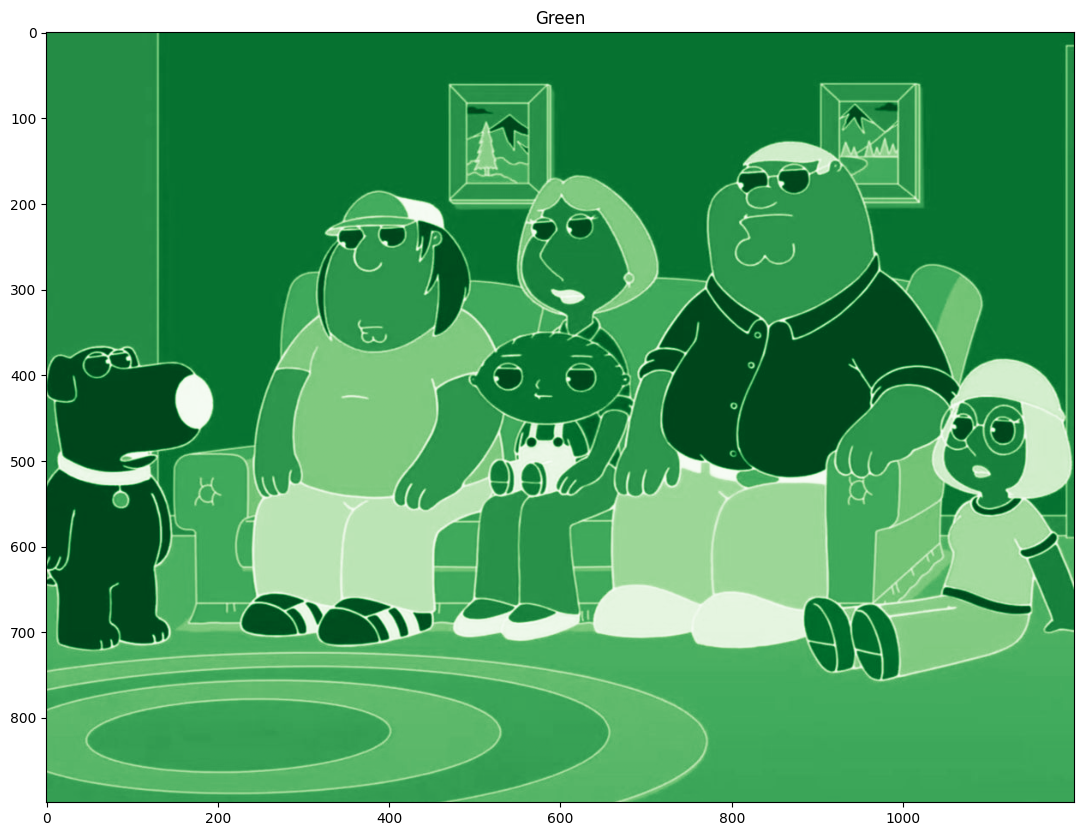

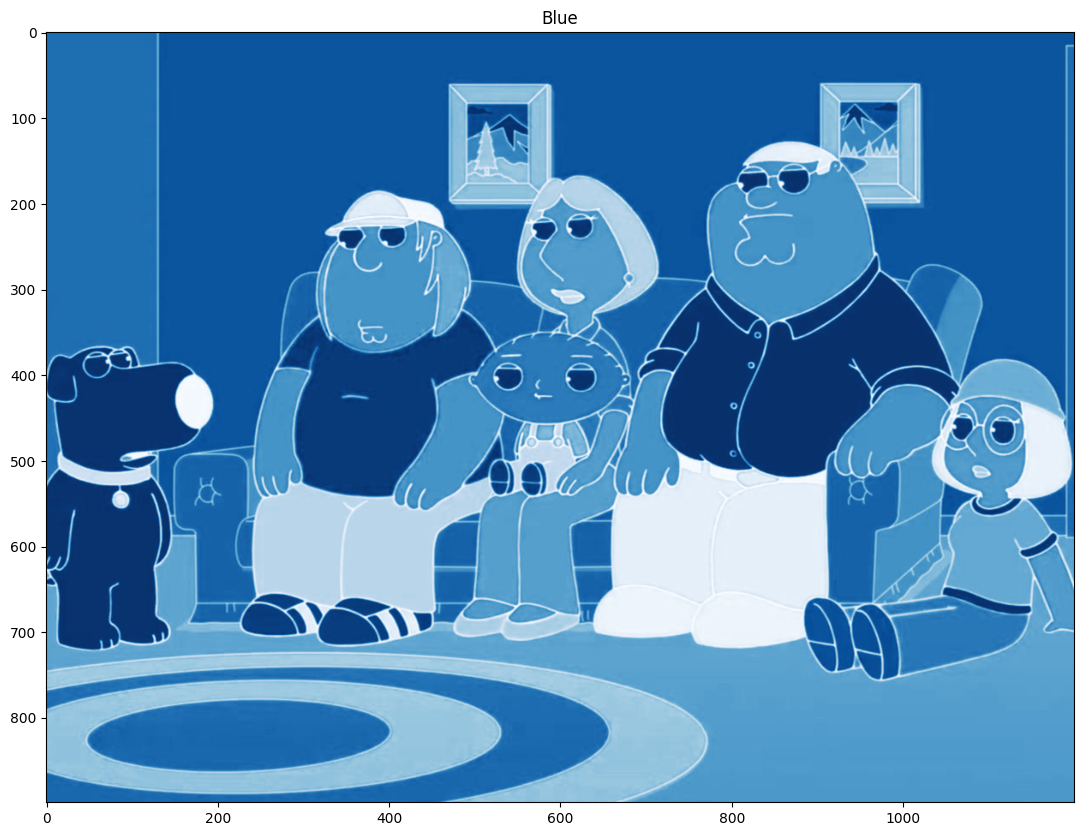

In [11]:
for i, (cmap, color) in enumerate(
    zip(
        [cm.Reds, cm.Greens, cm.Blues],
        ['Red', 'Green', 'Blue']
    )
):
    plt.figure(figsize=(20, 10))
    plt.imshow(img[i], cmap=cmap)
    plt.title(color)
    plt.show()

In [12]:
img.min(), img.max()

(tensor(0, dtype=torch.uint8), tensor(255, dtype=torch.uint8))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9074173..1.8949299].


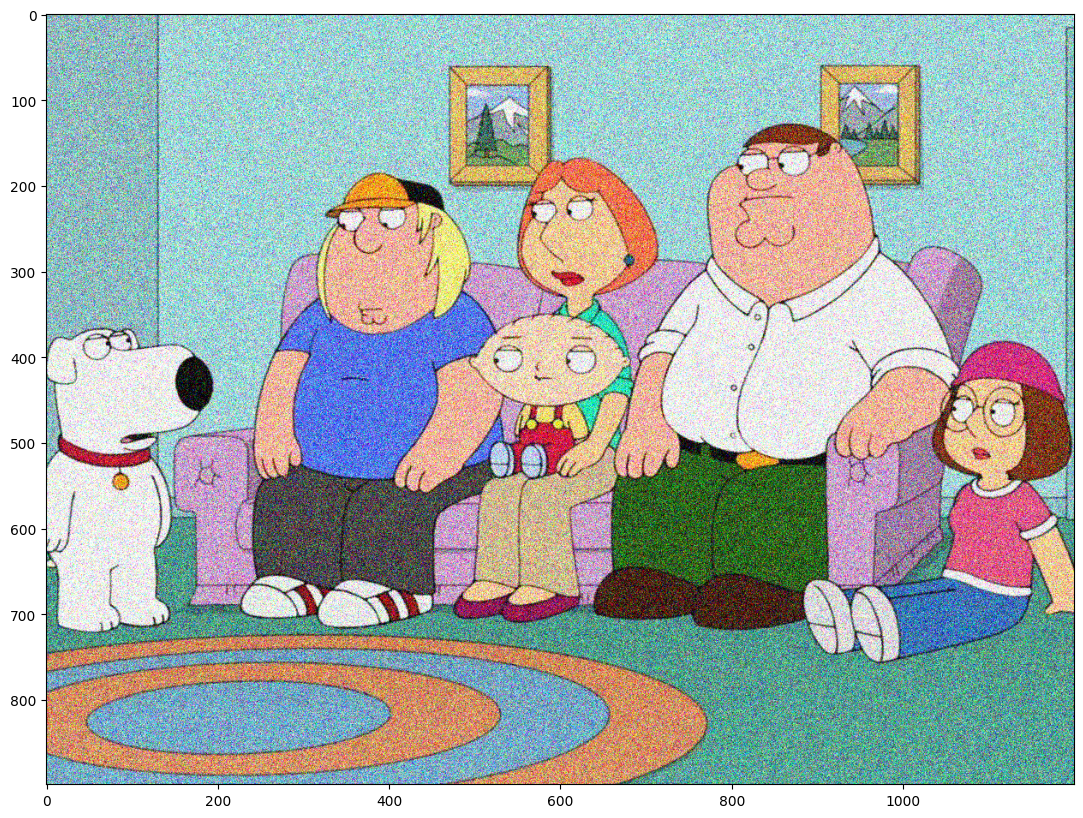

In [13]:
img01 = img / 255.0
noise_photo = img01 + torch.randn_like(img01) * 0.2

plt.figure(figsize=(20, 10))
plt.imshow(noise_photo.permute(1, 2, 0))
plt.show()

Когда мы хотим учить нейросети на изображениях, резонно использовать изображения, где значение пикселей находится в диапазоне 0-1, а не в 0-255, потому что
* Тогда не будут взрываться градиенты. Численная стабильность.
* Ускорение обучения: градиентный спуск сходится быстрее при нормализованных данных.
* Совместимость с активациями: многие функции активации (например, sigmoid, tanh) эффективнее в диапазоне [0,1] или [–1,1], поэтому нормализованные входы лучше «вписываются» в архитектуру.
* Стандартная практика: большинство современных фреймворков и предобученных моделей ожидают входы в диапазоне [0,1].

In [14]:
img = img / 255.0

## Свертка

<img src="simple_conv.png" width="600" />

Свертка в `PyTorch` представлена модулем `nn.Conv2d` со следующими параметрами:

- in_channels (int) – Количество каналов во входном изображении

- out_channels (int) – Количество каналов в выходном изображении

- kernel_size (int or tuple) – Размер ядра свертки

- stride (int or tuple, optional) – Страйд (шаг ядра свертки). По умолчанию: 1

- padding (int, tuple or str, optional) – Размер паддинга. По умолчанию: 0

- padding_mode (string, optional) – 'zeros', 'reflect', 'replicate' or 'circular'. По умолчанию: 'zeros'

- dilation (int or tuple, optional) – Дилейшн (шаг между элементами внутри ядра). По умолчанию: 1

- bias (bool, optional) – добавлять ли обучаемый сдвиг. По умолчанию: True

- groups (int, optional) – Количество групп, на которое разбиваются каналы. По умолчанию: 1

Про параметры ядра и паддинг, начальное понимание того, как применяется свертка. stride, padding, dilation.

https://github.com/vdumoulin/conv_arithmetic

Про padding_mode


| Режим       | Результат для [1, 2, 3] (паддинг = 2) |
|-------------|------------------------------------------|
| zeros   | [0, 0, **1, 2, 3**, 0, 0]                 |
| reflect | [2, 1, **1, 2, 3**, 3, 2]                 |
| replicate| [1, 1, **1, 2, 3**, 3, 3]                |
| circular| [2, 3, **1, 2, 3**, 1, 2]                 |

Про in_channels, out_channels, kernel_size

In [15]:
conv = nn.Conv2d(
    in_channels=4,
    out_channels=2,
    kernel_size=3,
    # stride = 1
    # padding = 0
    # dilation = 1
    # groups = 1
)
conv.weight.shape, conv.bias.shape

(torch.Size([2, 4, 3, 3]), torch.Size([2]))

In [18]:
first_collection = torch.ones(1, 4, 3, 3)
second_collection = torch.ones(1, 4, 3, 3) + 1
collection = torch.cat([first_collection, second_collection], dim=0)
collection.shape

torch.Size([2, 4, 3, 3])

In [19]:
conv.weight = torch.nn.Parameter(collection)
conv.bias = torch.nn.Parameter(torch.zeros(conv.bias.shape))
input_ = torch.ones(1, 4, 5, 5)
result = conv(input_)
result.shape, result

(torch.Size([1, 2, 3, 3]),
 tensor([[[[36., 36., 36.],
           [36., 36., 36.],
           [36., 36., 36.]],
 
          [[72., 72., 72.],
           [72., 72., 72.],
           [72., 72., 72.]]]], grad_fn=<ConvolutionBackward0>))

In [20]:
first_collection = torch.ones(2, 2, 3, 3)
second_collection = torch.ones(2, 2, 3, 3) + 1
collection = torch.cat([first_collection, second_collection], dim=1)
collection.shape

torch.Size([2, 4, 3, 3])

In [21]:
conv.weight = torch.nn.Parameter(collection)
conv.bias = torch.nn.Parameter(torch.zeros(conv.bias.shape))
input_ = torch.ones(1, 4, 5, 5)
result = conv(input_)
result.shape, result

(torch.Size([1, 2, 3, 3]),
 tensor([[[[54., 54., 54.],
           [54., 54., 54.],
           [54., 54., 54.]],
 
          [[54., 54., 54.],
           [54., 54., 54.],
           [54., 54., 54.]]]], grad_fn=<ConvolutionBackward0>))

In [17]:
conv.weight = torch.nn.Parameter(torch.ones(conv.weight.shape))
conv.bias = torch.nn.Parameter(torch.ones(conv.bias.shape))
input_ = torch.ones(1, 4, 5, 5)
result = conv(input_)
result.shape, result

(torch.Size([1, 2, 3, 3]),
 tensor([[[[37., 37., 37.],
           [37., 37., 37.],
           [37., 37., 37.]],
 
          [[37., 37., 37.],
           [37., 37., 37.],
           [37., 37., 37.]]]], grad_fn=<ConvolutionBackward0>))

Про grouped conv

In [22]:
conv = nn.Conv2d(
    in_channels=4,
    out_channels=2,
    kernel_size=3,
    # stride = 1
    # padding = 0
    # dilation = 1
    groups = 2
)
conv.weight.shape, conv.bias.shape

(torch.Size([2, 2, 3, 3]), torch.Size([2]))

Проверим, что in_channels и out_channels должны делиться на groups

In [23]:
conv = nn.Conv2d(
    in_channels=3,
    out_channels=12,
    kernel_size=3,
    # stride = 1
    # padding = 0
    # dilation = 1
    groups = 2
)

ValueError: in_channels must be divisible by groups

In [24]:
conv = nn.Conv2d(
    in_channels=4,
    out_channels=11,
    kernel_size=3,
    # stride = 1
    # padding = 0
    # dilation = 1
    groups = 2
)

ValueError: out_channels must be divisible by groups

Как изменятся ширина и высота после применения свертки

In [25]:
conv = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    # stride = 1
    # padding = 0
    # dilation = 1
    # groups = 1
)

In [26]:
img.shape

torch.Size([3, 899, 1200])

In [27]:
(1200 + 2 * 0 - 1 * 2 - 1) / 1 + 1

1198.0

$\begin{aligned} & H_{\text {out }}=\left\lfloor\frac{H_{\text {in }}+2 \times \text { padding }[0]-\operatorname{dilation}[0] \times(\text { kernel size }[0]-1)-1}{\text { stride }[0]}+1\right\rfloor \\ & W_{\text {out }}=\left\lfloor\frac{W_{\text {in }}+2 \times \text { padding }[1]-\operatorname{dilation}[1] \times(\text { kernel size }[1]-1)-1}{\operatorname{stride}[1]}+1\right\rfloor\end{aligned}$

In [28]:
conv(img).shape

torch.Size([10, 897, 1198])

In [29]:
conv = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    # stride = 1
    padding = 1
    # dilation = 1
    # groups = 1
)
conv(img).shape

torch.Size([10, 899, 1200])

In [30]:
conv = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    # stride = 1
    padding = 'same'
    # dilation = 1
    # groups = 1
)
conv(img).shape

torch.Size([10, 899, 1200])

Интересный факт: любою свертку можно задать и линейным слоем. 

Как применятеся свертка:

<batch, in_channels, in_H, in_W> -> [conv] -> <batch, out_channels, out_H, out_W>

Мы воздействуем сверткой на последние 2 размерности.

Линейный слой воздействует только на последнюю размерность, поэтому то же самое можно проделать при помощи линейного слоя так:

<batch, in_channels, in_H, in_W> -> [reshape] -> <bach, in_channels * in_H * in_W> -> [linear] -> <bach, out_channels * out_H * out_W> -> <batch, out_channels, out_H, out_W>

### Depthwise и Pointwise свертки

<img src="depthwise.png" width="600" />

In [31]:
conv = nn.Conv2d(
    in_channels=3,
    out_channels=3,
    kernel_size=5,
    groups=3
)
conv.weight = torch.nn.Parameter(torch.ones(conv.weight.shape))
conv.bias = torch.nn.Parameter(torch.zeros(conv.bias.shape))
input_ = torch.ones(1, 3, 12, 12)
result = conv(input_)
result.shape, result

(torch.Size([1, 3, 8, 8]),
 tensor([[[[25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.]],
 
          [[25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.]],
 
          [[25., 25., 25., 25., 25., 25., 25., 25.],
           [25., 25., 25., 25., 25., 25., 25., 25.],
           [2

<img src="pointwise.png" width="600" />

In [32]:
conv = nn.Conv2d(
    in_channels=3,
    out_channels=1,
    kernel_size=1,
)
conv.weight = torch.nn.Parameter(torch.ones(conv.weight.shape))
conv.bias = torch.nn.Parameter(torch.zeros(conv.bias.shape))
input_ = torch.ones(1, 3, 8, 8)
result = conv(input_)
result.shape, result

(torch.Size([1, 1, 8, 8]),
 tensor([[[[3., 3., 3., 3., 3., 3., 3., 3.],
           [3., 3., 3., 3., 3., 3., 3., 3.],
           [3., 3., 3., 3., 3., 3., 3., 3.],
           [3., 3., 3., 3., 3., 3., 3., 3.],
           [3., 3., 3., 3., 3., 3., 3., 3.],
           [3., 3., 3., 3., 3., 3., 3., 3.],
           [3., 3., 3., 3., 3., 3., 3., 3.],
           [3., 3., 3., 3., 3., 3., 3., 3.]]]], grad_fn=<ConvolutionBackward0>))

### Conv1d

In [33]:
conv = nn.Conv1d(
    in_channels=3,
    out_channels=2,
    kernel_size=3,
    # stride = 1
    # padding = 0
)
conv.weight.shape, conv.bias.shape

(torch.Size([2, 3, 3]), torch.Size([2]))

In [34]:
conv.weight = torch.nn.Parameter(torch.ones(conv.weight.shape))
conv.bias = torch.nn.Parameter(torch.zeros(conv.bias.shape))
input_ = torch.ones(1, 3, 8)
result = conv(input_)
result.shape, result

(torch.Size([1, 2, 6]),
 tensor([[[9., 9., 9., 9., 9., 9.],
          [9., 9., 9., 9., 9., 9.]]], grad_fn=<ConvolutionBackward0>))

## Пулинг

Пулинг представлен в модуле `torch.nn`, в основном будем использовать `MaxPool2d` и `AvgPool2d`.

Параметры:

- kernel_size – размер окошка

- stride – страйд окошка. По умолчанию равен kernel_size

- padding – сколько нулевого паддинга добавлять по краям. По умолчанию: 0.

In [35]:
img_tensor = torch.randint(0, 10, size=(10, 10), dtype=torch.float32).unsqueeze(0)

In [36]:
img_tensor

tensor([[[7., 4., 7., 8., 5., 5., 3., 9., 5., 9.],
         [8., 9., 6., 6., 0., 8., 7., 5., 7., 5.],
         [8., 4., 7., 1., 5., 9., 1., 1., 0., 7.],
         [4., 2., 9., 8., 3., 8., 1., 4., 0., 8.],
         [4., 7., 5., 9., 2., 1., 0., 7., 3., 6.],
         [8., 9., 2., 8., 0., 8., 9., 3., 6., 4.],
         [8., 1., 9., 2., 0., 9., 5., 2., 1., 2.],
         [7., 2., 5., 9., 4., 4., 9., 4., 1., 7.],
         [9., 2., 4., 3., 4., 5., 9., 9., 3., 9.],
         [0., 2., 7., 9., 9., 4., 8., 9., 9., 2.]]])

In [37]:
pooling1 = nn.MaxPool2d(kernel_size=2)

In [38]:
pooling1(img_tensor)

tensor([[[9., 8., 8., 9., 9.],
         [8., 9., 9., 4., 8.],
         [9., 9., 8., 9., 6.],
         [8., 9., 9., 9., 7.],
         [9., 9., 9., 9., 9.]]])

In [39]:
pooling2 = nn.AvgPool2d(kernel_size=2)

In [40]:
pooling2(img_tensor)

tensor([[[7.0000, 6.7500, 4.5000, 6.0000, 6.5000],
         [4.5000, 6.2500, 6.2500, 1.7500, 3.7500],
         [7.0000, 6.0000, 2.7500, 4.7500, 4.7500],
         [4.5000, 6.2500, 4.2500, 5.0000, 2.7500],
         [3.2500, 5.7500, 5.5000, 8.7500, 5.7500]]])